# Análisis Inicial

## Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Configuramos que se muestren todas las columnas de nuestros dataframes
pd.set_option('display.max_columns', None)

## Introducción al Análisis Exploratorio de Datos (EDA)

En esta fase del proyecto se realiza un análisis exploratorio de los datos limpios resultantes de dos datasets relacionados con la suscripción a un producto o servicio. El objetivo principal del EDA es comprender en profundidad las características del conjunto de datos, descubrir patrones, relaciones y diferencias significativas, y validar o generar hipótesis que guíen las etapas posteriores de análisis o modelado.

Se prestará especial atención a la variable de suscripción, buscando identificar:

- Los perfiles sociodemográficos predominantes, diferenciando clientes que se suscriben frente a los que no.
- Las variables económicas y su posible influencia en la decisión de suscribirse.
- La distribución temporal y el impacto de distintos canales de contacto.
- Las relaciones e interacciones entre variables relevantes para explicar el fenómeno de suscripción.



## Unificación de la información (Merge de ambas tablas)

In [3]:
df_bank = pd.read_csv('files/output/df_bank_clean.csv')

In [4]:
df_bank.columns

Index(['AGE', 'JOB', 'MARITAL', 'EDUCATION', 'DEFAULT', 'HOUSING', 'LOAN',
       'CONTACT', 'DURATION', 'CAMPAIGN', 'PDAYS', 'PREVIOUS', 'POUTCOME',
       'EMPVARRATE', 'CONSPRICEIDX', 'CONSCONFIDX', 'EURIBOR3M', 'NREMPLOYED',
       'Y', 'DATE', 'ID', 'AGE_CAT', 'EDUCATION_GROUPED', 'WAS_CONTACTED',
       'DAYS_SINCE_CONTACT'],
      dtype='object')

In [5]:
df_customer = pd.read_csv('files/output/df_customer_clean.csv')

In [6]:
df_customer.columns

Index(['INCOME', 'KIDHOME', 'TEENHOME', 'DTCUSTOMER', 'NUMWEBVISITSMONTH',
       'ID'],
      dtype='object')

Comoprobamos la posibilidad de unificar la información de los dos dataframes:


In [7]:
assert df_bank['ID'].is_unique, "ID no es único en df1"
assert df_customer['ID'].is_unique, "ID no es único en df2"

In [8]:
ids_1 = set(df_bank['ID'])
ids_2 = set(df_customer['ID'])

ids_diff_1 = ids_1 - ids_2  # IDs en df1 no en df2
ids_diff_2 = ids_2 - ids_1  # IDs en df2 no en df1

print(f"IDs en df1 no en df2: {len(ids_diff_1)}")
print(f"IDs en df2 no en df1: {len(ids_diff_2)}")


IDs en df1 no en df2: 0
IDs en df2 no en df1: 418


Todos los ids de "df_bank" están presentes en "df_customer", que es el dataframe principal por lo que se toma la decisión unificarlos con un inner join, teniendo en cuenta que se perderan 418 registros del dataframe "df_customer".


In [9]:
df_complete = pd.merge(df_bank, df_customer, on="ID", how="inner")

In [10]:
df_complete.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42752 entries, 0 to 42751
Data columns (total 30 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   AGE                 42752 non-null  float64
 1   JOB                 42752 non-null  object 
 2   MARITAL             42752 non-null  object 
 3   EDUCATION           42752 non-null  object 
 4   DEFAULT             42752 non-null  object 
 5   HOUSING             42752 non-null  object 
 6   LOAN                42752 non-null  object 
 7   CONTACT             42752 non-null  object 
 8   DURATION            42752 non-null  int64  
 9   CAMPAIGN            42752 non-null  int64  
 10  PDAYS               42752 non-null  int64  
 11  PREVIOUS            42752 non-null  int64  
 12  POUTCOME            42752 non-null  object 
 13  EMPVARRATE          42752 non-null  float64
 14  CONSPRICEIDX        42752 non-null  float64
 15  CONSCONFIDX         42752 non-null  float64
 16  EURI

Las columnas de fecha vuelven a ser object al traerlas desde el csv limpio, por lo que las volvemos a convertir a datetime.

In [11]:
df_complete[["DATE", "DTCUSTOMER"]].dtypes

DATE          object
DTCUSTOMER    object
dtype: object

In [12]:
df_complete[["DATE", "DTCUSTOMER"]].sample(1)

,DATE,DTCUSTOMER
14017,2016-07-22,2012-11-25


In [13]:
df_complete['DATE'] = pd.to_datetime(df_complete['DATE'])
df_complete['DTCUSTOMER'] = pd.to_datetime(df_complete['DTCUSTOMER'])

In [14]:
df_complete[["DATE", "DTCUSTOMER"]].dtypes

DATE          datetime64[ns]
DTCUSTOMER    datetime64[ns]
dtype: object

Ordenamos el dataframe:

In [15]:
# 1. Obtener el nombre de las columnas
columnas = df_complete.columns.tolist()

# 2. Crear la nueva lista con 'id' primero
nueva_lista_ordenada = ['ID'] + ['Y']+ [col for col in columnas if col != 'ID' and col != 'Y']

# 3. Reordenar las columnas usando reindex
df_complete = df_complete.reindex(columns=nueva_lista_ordenada)

In [16]:
df_complete.sample(2)

,ID,Y,AGE,JOB,MARITAL,EDUCATION,DEFAULT,HOUSING,LOAN,CONTACT,DURATION,CAMPAIGN,PDAYS,PREVIOUS,POUTCOME,EMPVARRATE,CONSPRICEIDX,CONSCONFIDX,EURIBOR3M,NREMPLOYED,DATE,AGE_CAT,EDUCATION_GROUPED,WAS_CONTACTED,DAYS_SINCE_CONTACT,INCOME,KIDHOME,TEENHOME,DTCUSTOMER,NUMWEBVISITSMONTH
39538,38462f6c-5dc0-4425-8583-27311f1da239,no,32.0,technician,single,university-degree,no,yes,yes,cellular,288,1,999,0,nonexistent,-1.7,94.055,-39.8,0.742,4991.6,2017-01-14,25-34,university-degree,no,NaN,72330,0,2,2014-05-27,31
29912,dafa096e-1268-4487-a3bb-582b38f7964a,no,35.0,management,married,university-degree,no,yes,no,cellular,878,1,999,0,nonexistent,-1.8,93.075,-47.1,1.365,5099.1,2018-05-03,35-44,university-degree,no,NaN,67497,0,1,2014-04-21,26


## Relación entre variables categóricas con la variable objetivo (Y)

In [17]:
# Creamos un sub-dataframe de columnas categóricas/booleanas
cat_complete= df_complete.select_dtypes(include=['category', 'object', 'bool']).columns

In [18]:
cat_complete = cat_complete.drop([ "ID","EDUCATION"])

In [19]:
df_complete[cat_complete].sample(1)

,Y,JOB,MARITAL,DEFAULT,HOUSING,LOAN,CONTACT,POUTCOME,AGE_CAT,EDUCATION_GROUPED,WAS_CONTACTED
23150,no,technician,married,no,yes,no,cellular,nonexistent,45-54,professional-course,no


In [20]:
cat_cols = cat_complete.drop(["Y"])

In [21]:
cat_cols

Index(['JOB', 'MARITAL', 'DEFAULT', 'HOUSING', 'LOAN', 'CONTACT', 'POUTCOME',
       'AGE_CAT', 'EDUCATION_GROUPED', 'WAS_CONTACTED'],
      dtype='object')

Visualizamos la distribución de la variable objetivo Y en relación a cada una de las variables categóricas.

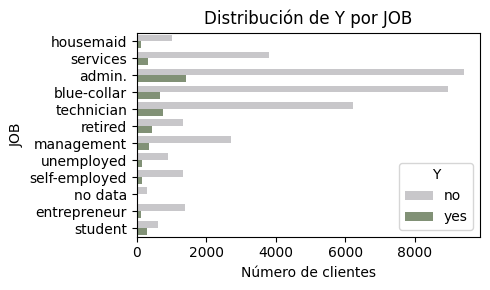

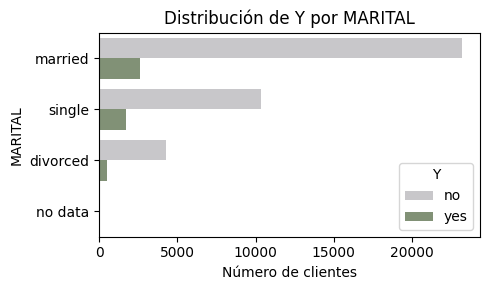

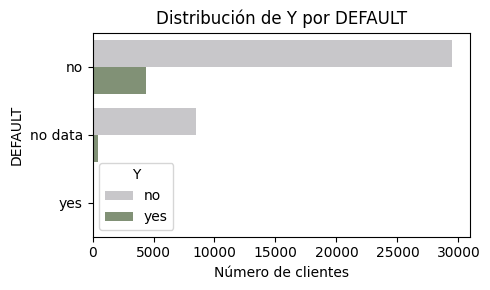

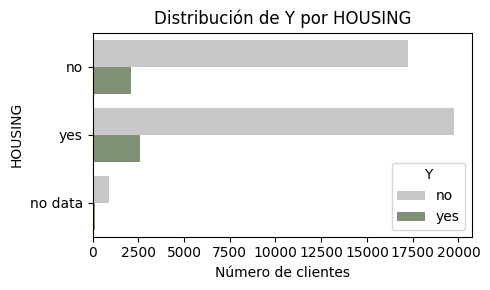

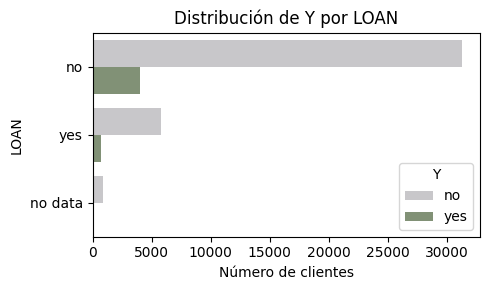

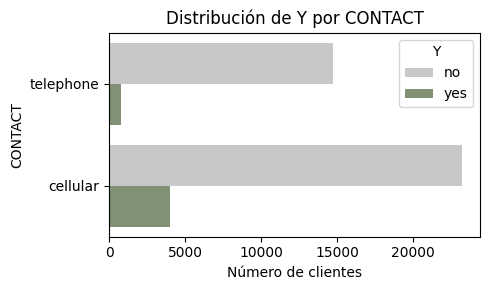

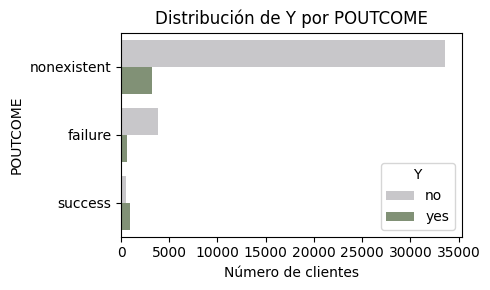

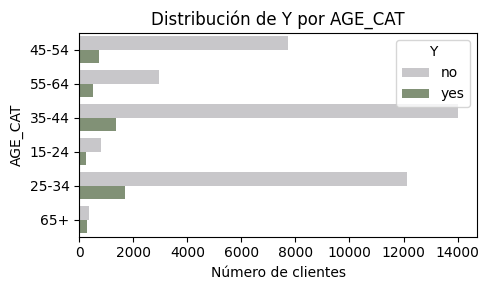

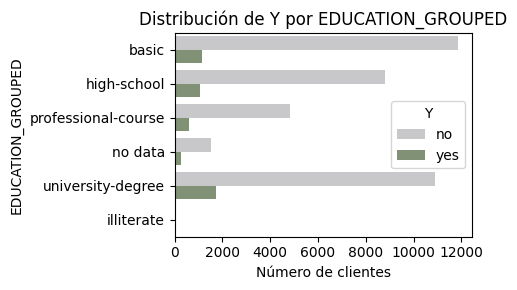

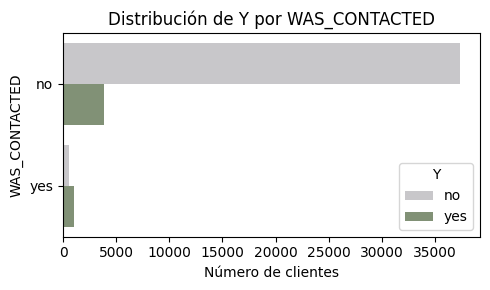

In [22]:
for col in cat_cols:
    plt.figure(figsize=(5,3))
    sns.countplot(
        data=df_complete,
        y=col,
        hue='Y',
        palette={'no': '#C8C6CB',  
                 'yes': '#809671'}  
    )
    plt.title(f'Distribución de Y por {col}')
    plt.xlabel('Número de clientes')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

La visualización en crudo no nos aporta mucha información facilmente interpretable para el ojo humano, así que optamos por graficos de barras para ver la proporción de "yes" en cada categoría.

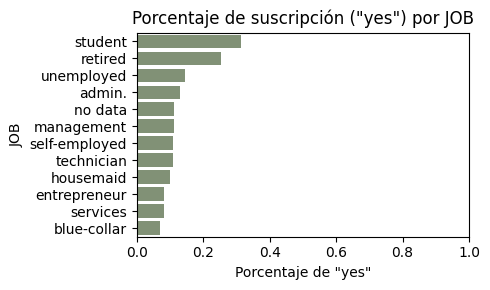

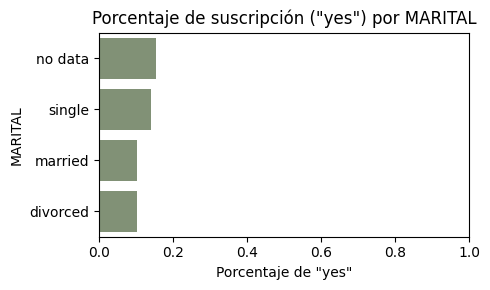

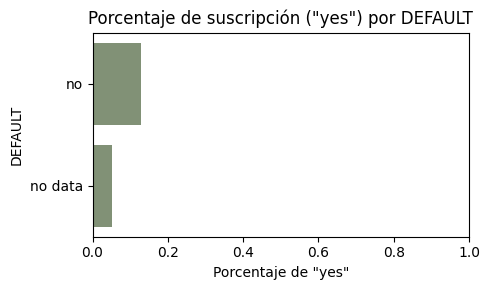

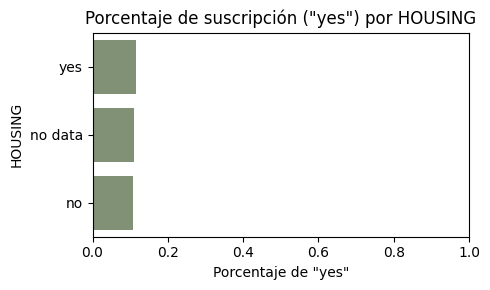

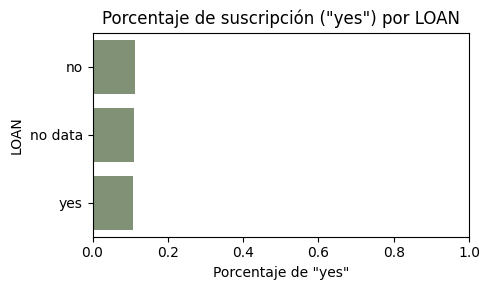

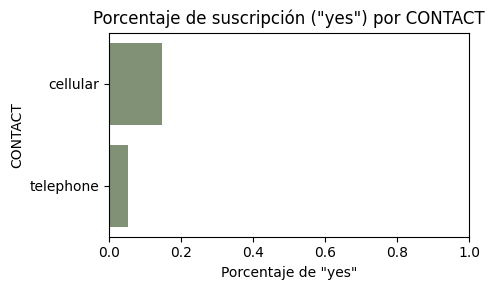

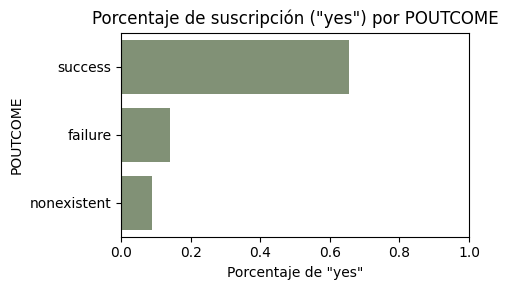

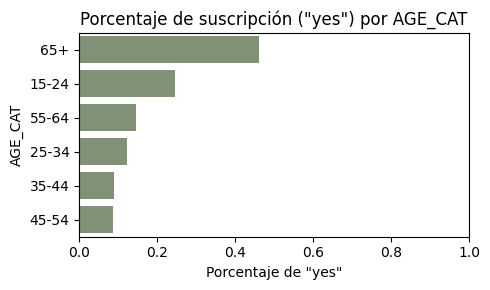

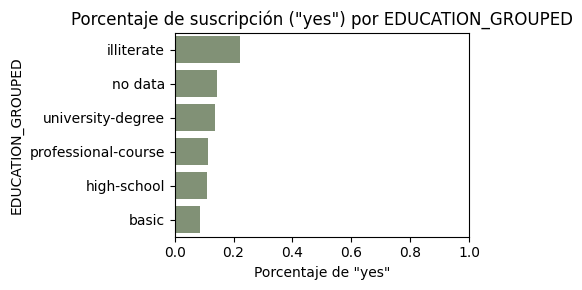

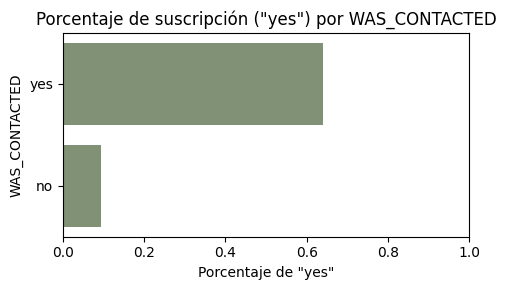

In [23]:
for col in cat_cols:
    tabla_yes = (df_complete.groupby(col)['Y'].value_counts(normalize=True).rename('perc').reset_index())
    tabla_yes = tabla_yes[tabla_yes['Y'] == 'yes'].sort_values('perc', ascending=False)

    plt.figure(figsize=(5,3))
    sns.barplot(data=tabla_yes, x='perc', y=col, color='#809671')
    plt.xlabel('Porcentaje de "yes"')
    plt.ylabel(col)
    plt.title(f'Porcentaje de suscripción ("yes") por {col}')
    plt.xlim(0, 1)
    plt.tight_layout()
    plt.show()

In [24]:
# Análisis de la variable EDUCATION_GROUPED pre-conclusiones
df_complete["EDUCATION_GROUPED"].value_counts()

EDUCATION_GROUPED
basic                  12986
university-degree      12642
high-school             9872
professional-course     5440
no data                 1794
illiterate                18
Name: count, dtype: int64

### Conclusiones Variables Categóricas:

1. `Efecto de campañas previas (POUTCOME)`

Los clientes cuya campaña anterior finalizó con éxito presentan una probabilidad de suscripción actual claramente superior al resto, con tasas que rondan el 65 %. Este resultado sugiere un fuerte efecto de “éxito pasado”, donde una experiencia positiva previa incrementa notablemente la predisposición a aceptar nuevas ofertas comerciales. Desde el punto de vista de negocio, este colectivo constituye un segmento de alto valor que debería priorizarse sistemáticamente en futuras campañas.

2. `Contacto previo con el cliente (WAS_CONTACTED)`

Los clientes que habían sido contactados previamente en una campaña (WAS_CONTACTED = "yes") presentan una probabilidad de suscripción del 64.1%, una cifra drásticamente superior al 9.2% observado en aquellos sin historial de contacto previo. Este diferencial masivo refuerza la relevancia de las relaciones recurrentes: mantener un historial de interacción con el cliente multiplica por más de 6 la disposición a contratar el producto, convirtiendo a este segmento en la prioridad absoluta para maximizar el retorno.

3. `Edad y situación laboral (AGE_CAT / JOB)`

El análisis por grupos de edad y situación laboral muestra que los estudiantes (grupo 15–24 años) y los jubilados (65+ años) alcanzan las tasas de conversión más elevadas, en un rango aproximado del 25 % al 46 %. En contraste, los clientes en edad laboral intermedia (aprox. 30–50 años) presentan probabilidades de suscripción significativamente menores, en torno al 8–10 %. Estos resultados apuntan a que los extremos del ciclo vital son más receptivos al producto, lo que justifica el diseño de mensajes y propuestas de valor específicos para estos dos segmentos.

4. `Importancia del canal de contacto (CONTACT)`

Se observa que las interacciones realizadas a través de teléfono móvil registran una tasa de éxito cercana al 14 %, prácticamente el triple de la obtenida mediante teléfono fijo (alrededor del 5 %). Este diferencial indica que el canal de contacto es un factor determinante en la efectividad de la campaña y respalda la recomendación de concentrar los esfuerzos de comunicación en canales móviles, tanto en términos de recursos como de diseño de estrategias.

5. `Nivel educativo (EDUCATION)`

El nivel educativo también muestra diferencias en las tasas de suscripción. El grupo clasificado como “illiterate” presenta porcentajes relativamente altos, seguido por los clientes con estudios universitarios. No obstante, el subconjunto de personas analfabetas es muy reducido (18 valores), por lo que estos resultados deben interpretarse con cautela para evitar conclusiones sobregeneralizadas. En cambio, el buen desempeño del segmento universitario, con una base muestral más amplia, ofrece una evidencia más sólida de que un mayor nivel educativo podría estar asociado a una mayor propensión a contratar el producto.

## Relación entre variables numéricas con la variable objetivo (Y)

In [25]:
num_cols = df_complete.select_dtypes(include=['float64','int64']).columns.tolist()
num_cols.remove("PDAYS")

df_complete.groupby('Y')[num_cols].describe().round(2)

AGE                                             DURATION          \
       count   mean    std   min   25%   50%   75%   max    count    mean   
Y                                                                           
no   37941.0  39.75   9.59  17.0  32.0  38.0  46.0  95.0  37941.0  220.39   
yes   4811.0  40.71  13.42  17.0  31.0  37.0  48.0  98.0   4811.0  552.56   

                                               CAMPAIGN                        \
        std   min    25%    50%    75%     max    count  mean   std  min  25%   
Y                                                                               
no   207.12   0.0   95.0  163.0  278.0  4918.0  37941.0  2.63  2.87  1.0  1.0   
yes  398.59  63.0  253.0  449.0  741.0  4199.0   4811.0  2.05  1.66  1.0  1.0   

                    PREVIOUS                                      EMPVARRATE  \
     50%  75%   max    count  mean   std  min  25%  50%  75%  max      count   
Y                                                                              
no   2.0  3.0  56.0  37941.0  0.13  0.41  0.0  0.0  0.0  0.0  7.0    37941.0   
yes  2.0  2.0  23.0   4811.0  0.50  0.87  0.0  0.0  0.0  1.0  6.0     4811.0   

                                         CONSPRICEIDX                     \
     mean   std  min  25%  50%  75%  max        count   mean   std   min   
Y                                                                          
no   0.24  1.49 -3.4 -1.8  1.1  1.4  1.4      37941.0  93.60  0.56  92.2   
yes -1.24  1.63 -3.4 -1.8 -1.8 -0.1  1.4       4811.0  93.36  0.68  92.2   

                                CONSCONFIDX                                 \
       25%    50%    75%    max       count   mean   std   min   25%   50%   
Y                                                                            
no   93.08  93.92  93.99  94.77     37941.0 -40.60  4.40 -50.8 -42.7 -41.8   
yes  92.89  93.20  93.92  94.77      4811.0 -39.77  6.16 -50.8 -46.2 -40.3   

                EURIBOR3M                                            \
      75%   max     count  mean   std   min   25%   50%   75%   max   
Y                                                                     
no  -36.4 -26.9   37941.0  3.81  1.64  0.63  1.40  4.86  4.96  5.04   
yes -36.1 -26.9    4811.0  2.11  1.74  0.63  0.84  1.27  4.23  4.97   

    NREMPLOYED                                                          \
         count     mean    std     min     25%     50%     75%     max   
Y                                                                        
no     37941.0  5176.04  64.69  4963.6  5099.1  5195.8  5228.1  5228.1   
yes     4811.0  5094.55  87.62  4963.6  5017.5  5099.1  5191.0  5228.1   

    DAYS_SINCE_CONTACT                                        INCOME  \
                 count  mean  std  min  25%  50%  75%   max    count   
Y                                                                      
no               566.0  6.25  4.0  0.0  3.0  6.0  9.0  22.0  37941.0   
yes             1011.0  5.98  3.8  0.0  3.0  6.0  6.0  27.0   4811.0   

                                                                       \
         mean       std     min      25%      50%       75%       max   
Y                                                                       
no   93297.23  50524.56  5848.0  49595.0  93152.0  136897.0  180802.0   
yes  92660.66  50270.01  5841.0  49521.5  92380.0  134694.0  180791.0   

     KIDHOME                                      TEENHOME                  \
       count  mean   std  min  25%  50%  75%  max    count mean   std  min   
Y                                                                            
no   37941.0  1.01  0.82  0.0  0.0  1.0  2.0  2.0  37941.0  1.0  0.82  0.0   
yes   4811.0  1.01  0.82  0.0  0.0  1.0  2.0  2.0   4811.0  1.0  0.82  0.0   

                        NUMWEBVISITSMONTH                                     \
     25%  50%  75%  max             count   mean   std  min  25%   50%   75%   
Y                                      

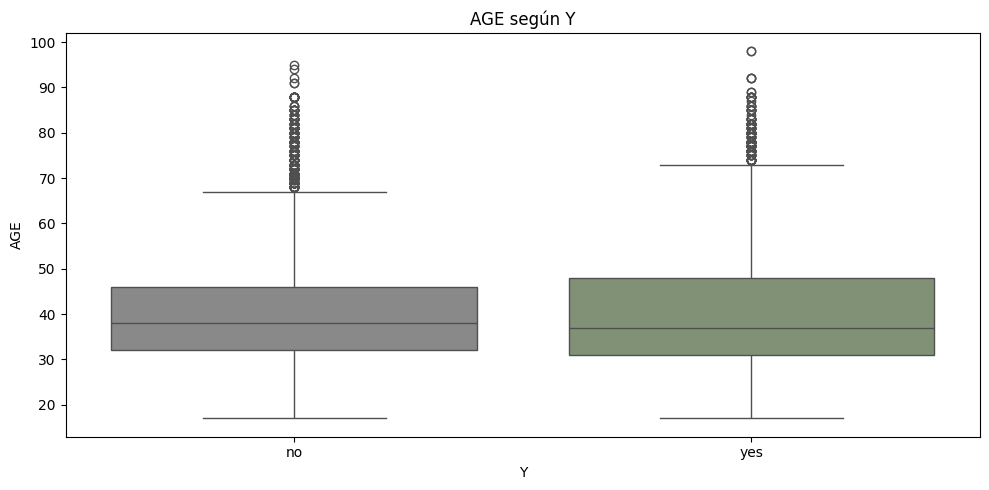

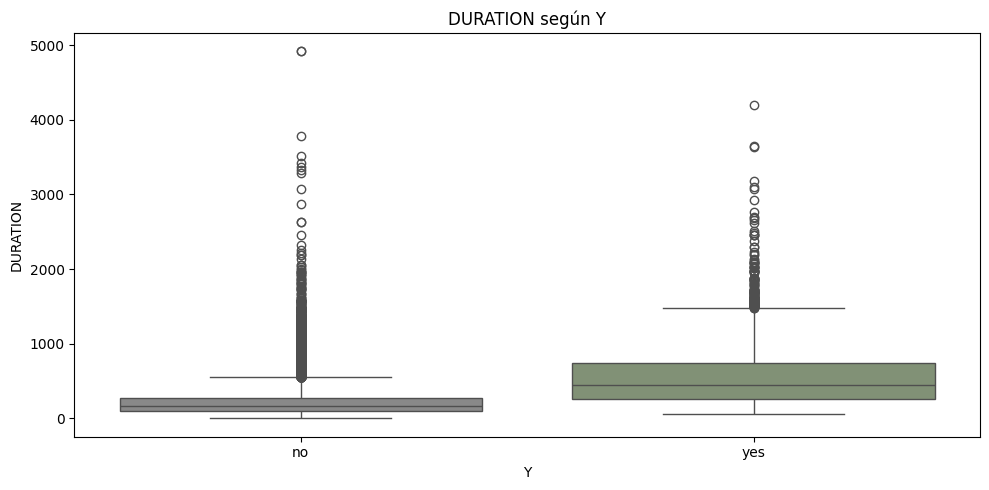

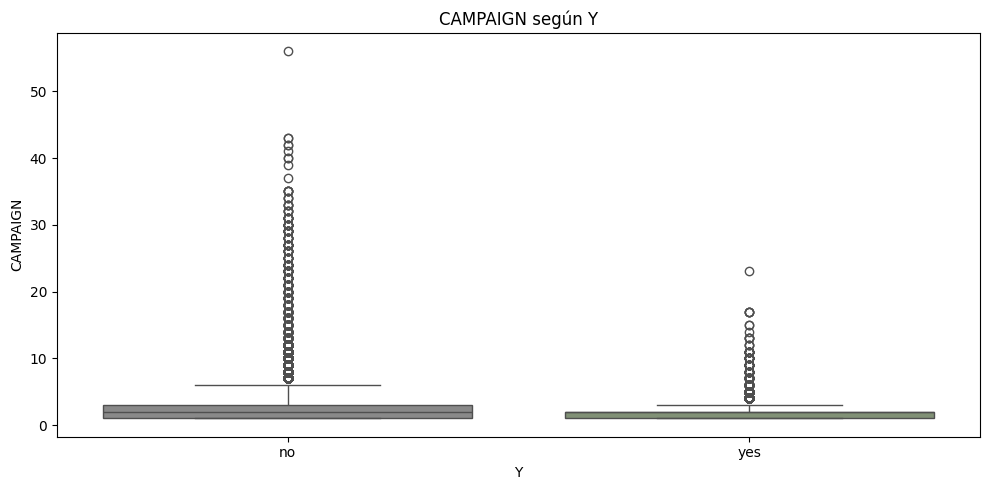

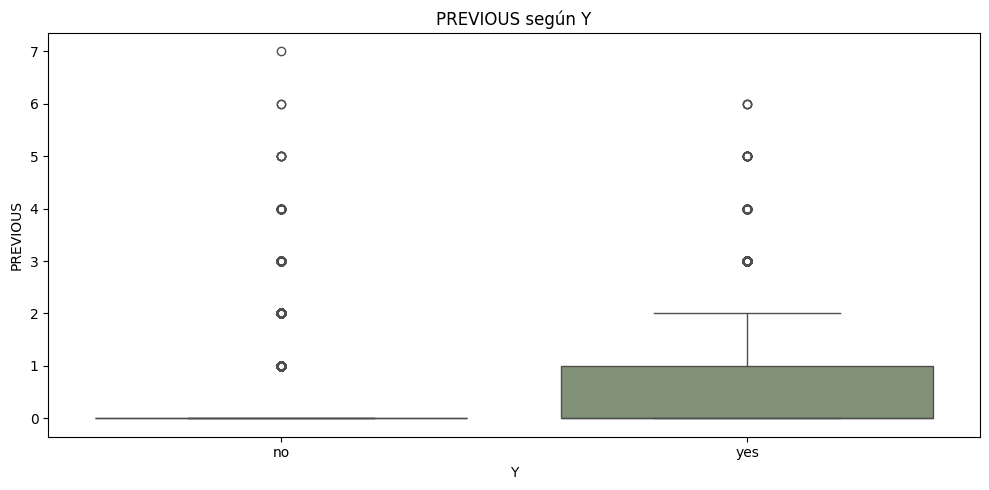

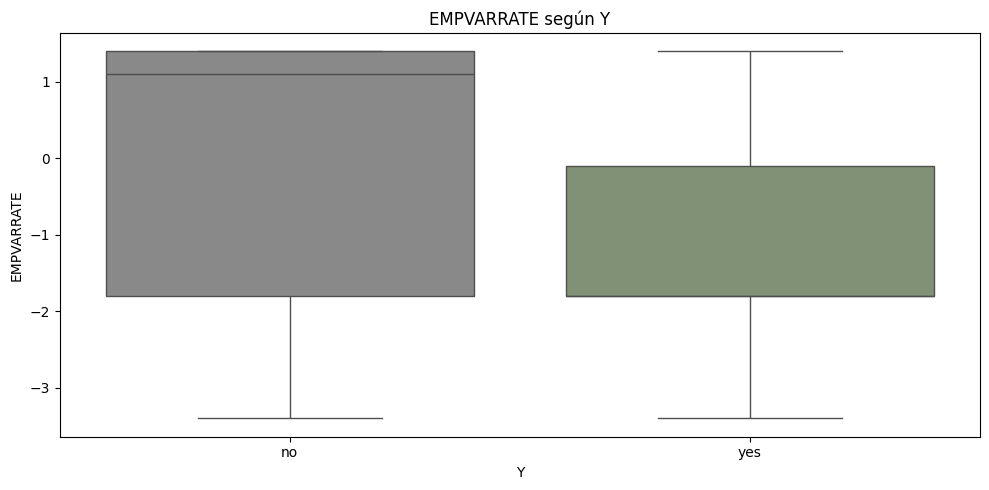

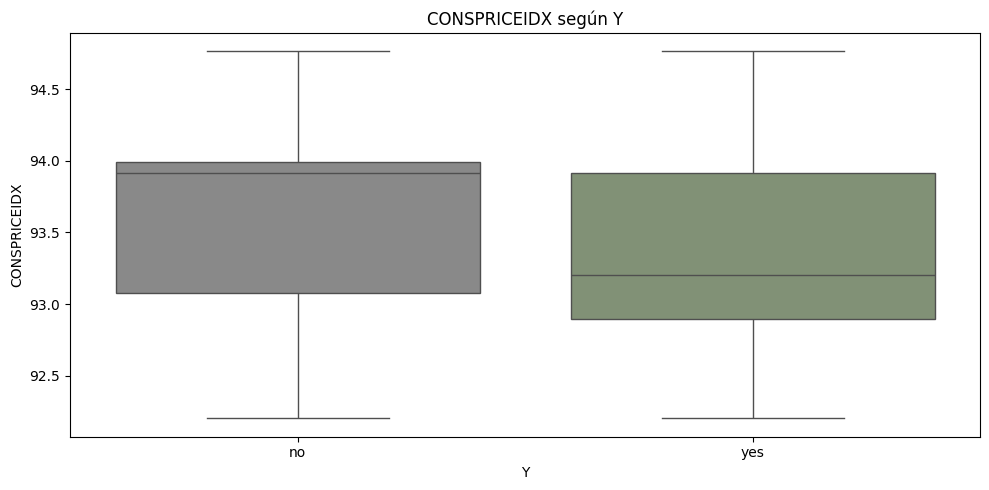

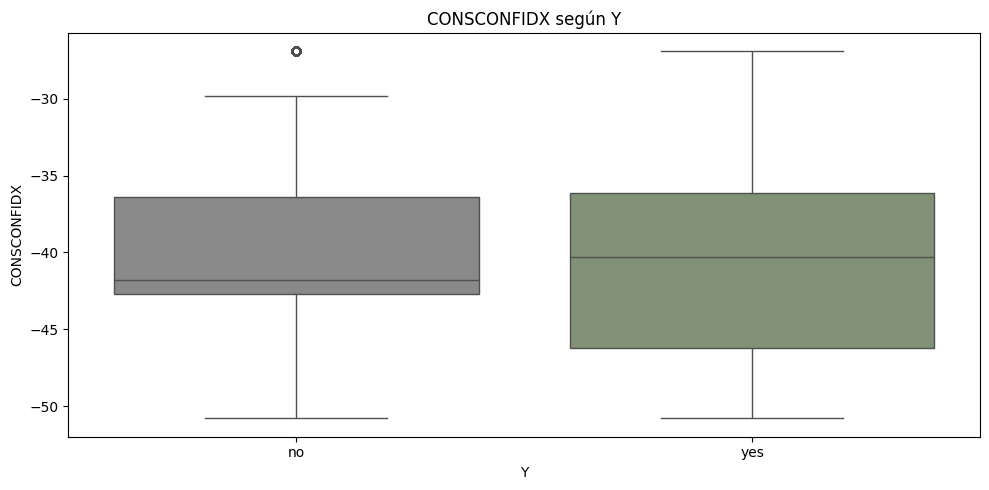

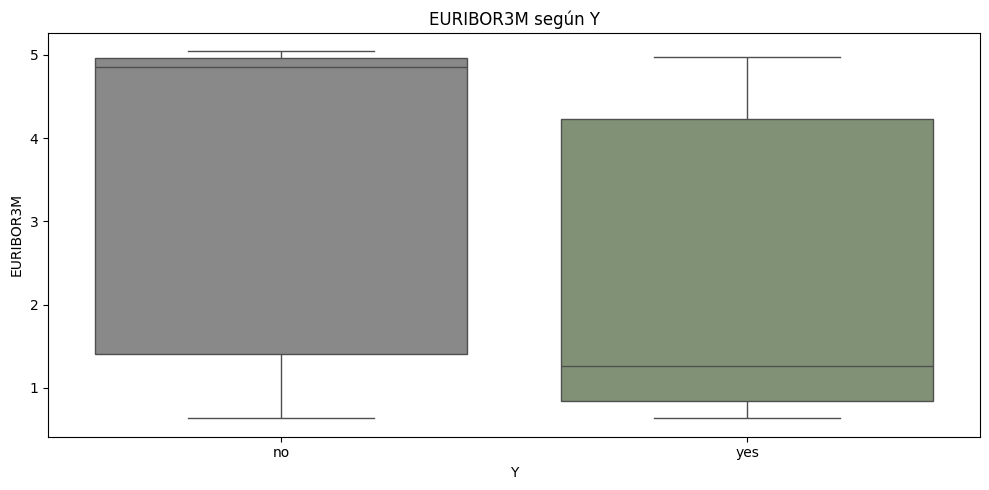

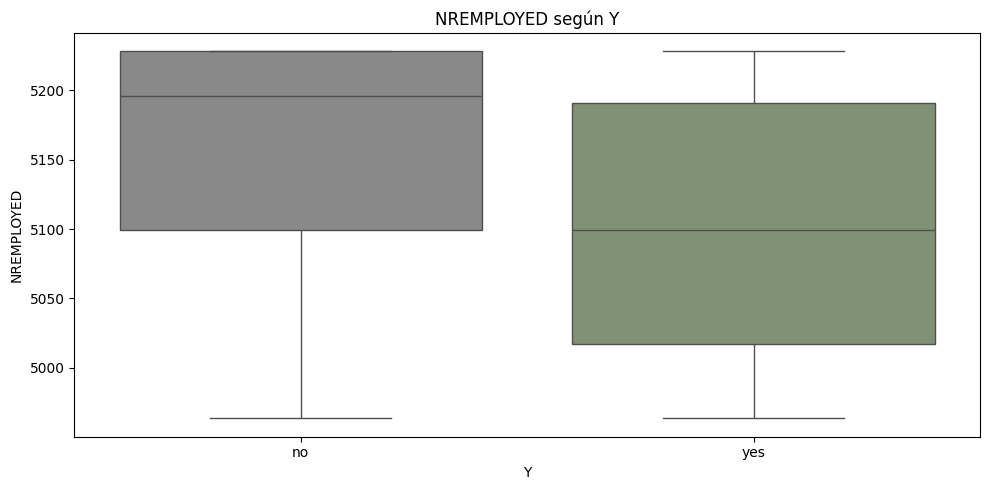

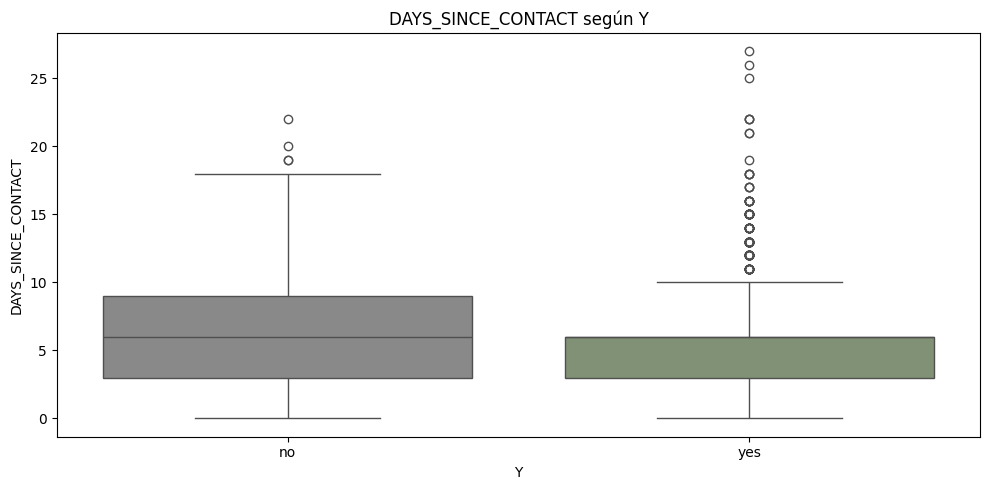

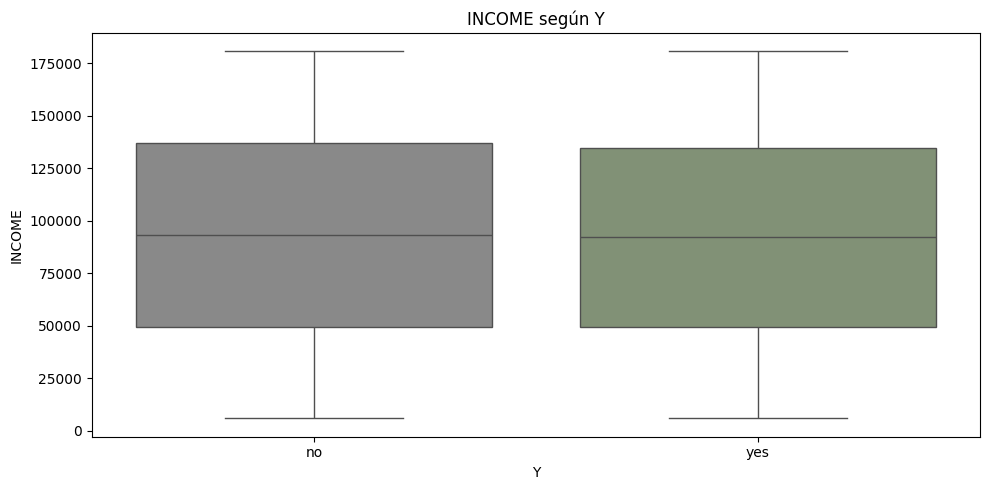

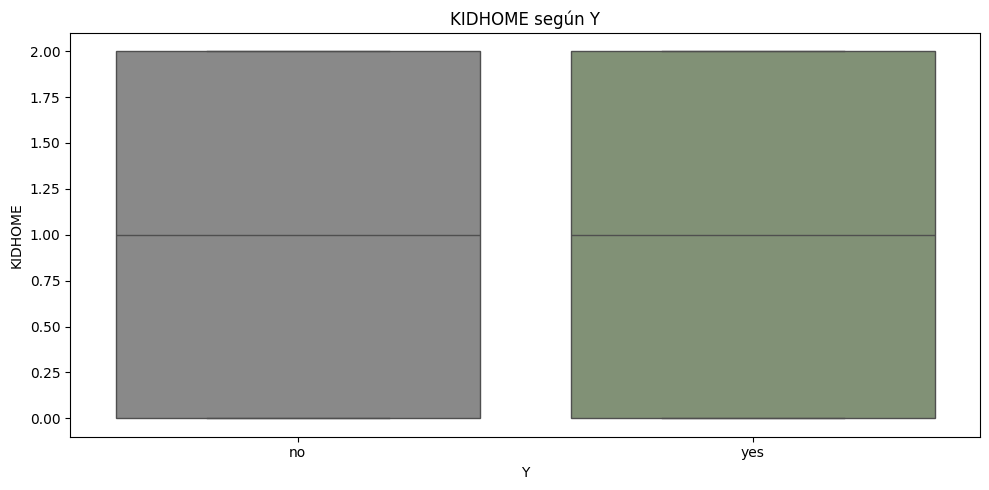

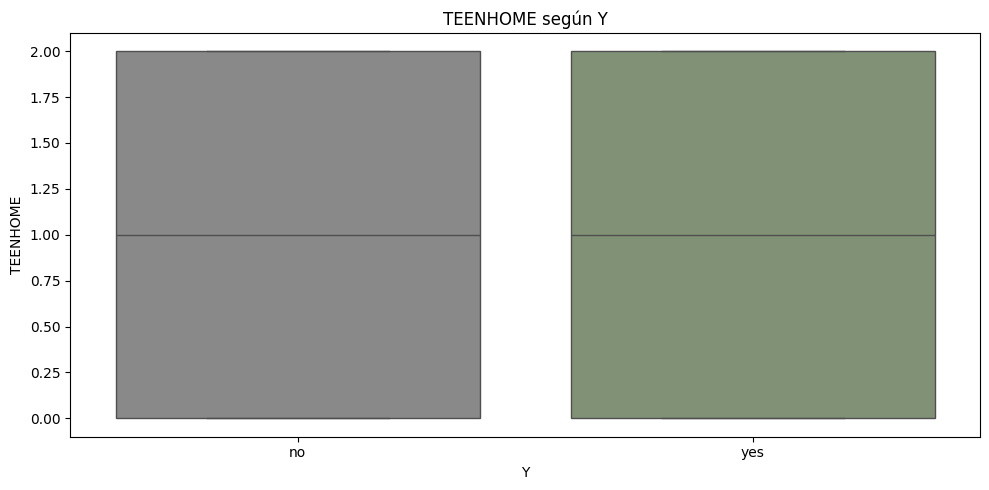

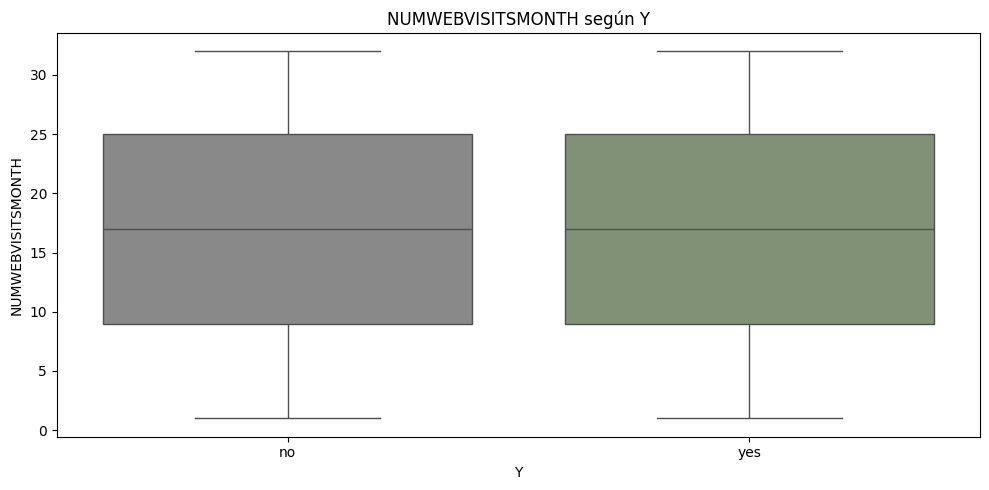

In [26]:
for col in num_cols:
    plt.figure(figsize=(10,5))
    sns.boxplot(
        data=df_complete,
        x='Y',
        y=col,
        hue='Y',
        palette={'no': '#898989', 'yes': '#809671'},
        dodge=False,   # para que se solapen en la misma posición
        legend=False,
    )
    plt.title(f'{col} según Y')
    plt.tight_layout()
    plt.show()

In [27]:
df_complete['Y_BIN'] = df_complete['Y'].map({'no': 0, 'yes': 1})

corrs = df_complete[num_cols + ['Y_BIN']].corr()['Y_BIN'].sort_values(ascending=False)
print(corrs)

Y_BIN                 1.000000
DURATION              0.405651
PREVIOUS              0.232944
CONSCONFIDX           0.057121
AGE                   0.029984
KIDHOME               0.000154
NUMWEBVISITSMONTH     0.000020
TEENHOME             -0.000488
INCOME               -0.003984
DAYS_SINCE_CONTACT   -0.033989
CAMPAIGN             -0.066304
CONSPRICEIDX         -0.135126
EMPVARRATE           -0.298201
EURIBOR3M            -0.308316
NREMPLOYED           -0.355707
Name: Y_BIN, dtype: float64


In [28]:
corr_matrix = df_complete[num_cols + ['Y_BIN']].corr()

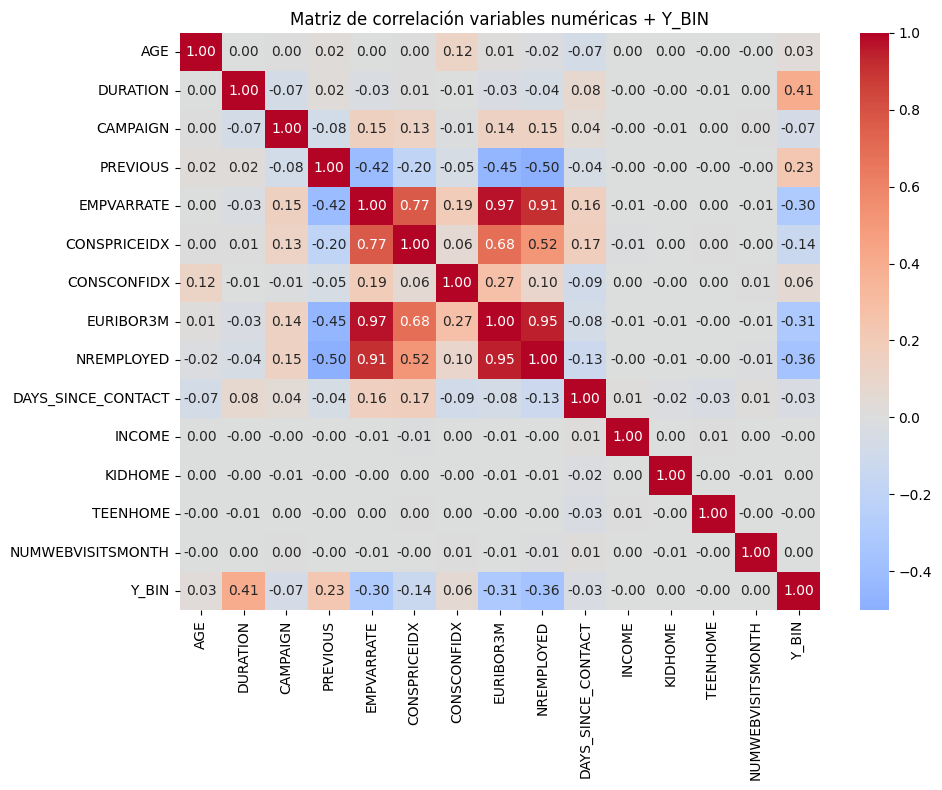

In [29]:
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=True, fmt='.2f', center=0)
plt.title('Matriz de correlación variables numéricas + Y_BIN')
plt.tight_layout()
plt.show()

### Conclusiones Variables Numericas:

1. `Duración del contacto (DURATION)`

Existe una diferencia drástica en la duración de las llamadas entre quienes se suscriben y quienes no. La media para los clientes que dicen "sí" es de 553 segundos (más de 9 minutos), frente a solo 220 segundos (menos de 4 minutos) para los que dicen "no". Aunque esta variable es la más predictiva, debe usarse con precaución en modelos de predicción en tiempo real, ya que la duración no se conoce antes de realizar la llamada. Sin embargo, confirma que mantener al cliente en línea es un indicador clave de interés.

2. `Indicadores económicos (EURIBOR3M, EMPVARRATE, NREMPLOYED)`

Se observa una clara relación inversa entre los indicadores económicos y la tasa de suscripción. Los clientes que contratan el producto lo hacen en contextos de tipos de interés más bajos (Euribor medio de 2.11 vs 3.81 para los no suscriptores) y tasas de variación de empleo negativas (EMPVARRATE medio de -1.24 vs 0.24). Esto sugiere que el producto (probablemente un depósito a plazo) se vuelve más atractivo como refugio seguro cuando el entorno económico es incierto o los tipos de interés bajan, o bien que las campañas son más agresivas en esos periodos.

3. `Historial de contactos previos (PREVIOUS)`

El número de contactos previos realizados antes de esta campaña es significativamente mayor en el grupo de suscriptores (media de 0.50) comparado con los no suscriptores (0.13). Esto refuerza la idea de que la persistencia moderada y el cultivo de la relación con el cliente a lo largo del tiempo aumentan la probabilidad de éxito. Un cliente que ya ha sido contactado anteriormente tiene mayor predisposición a escuchar.

4. `Días desde el último contacto (DAYS_SINCE_CONTACT)`

Al analizar el subgrupo de clientes que sí fueron contactados previamente, la diferencia en el tiempo de espera es sutil pero existente. Los suscriptores fueron contactados en promedio hace 5.9 días, frente a los 6.6 días de los no suscriptores. Aunque la mediana se sitúa en 6 días para ambos grupos, la ligera reducción en la media sugiere que la inmediatez juega a favor, aunque el factor determinante sigue ser el hecho de haber sido contactado (capturado por WAS_CONTACTED) más que la diferencia de un par de días en la recencia.

5. `Indicadores económicos (EURIBOR3M, EMPVARRATE, NREMPLOYED)`

Las tres variables macroeconómicas analizadas presentan una correlación negativa moderada con la suscripción, lo que indica que el producto se contrata con mayor frecuencia en contextos de tipos de interés más bajos, peores tasas de variación de empleo y menor número de empleados en el sector. Aunque no podemos determinar el motivo causal, si podemos observar que los episodios con peores indicadores laborales y tipos de interés más bajos coinciden con mayores tasas de suscripción

## Relación entre variables temporales con la variable objetivo (Y)

In [30]:
date_cols = df_complete.select_dtypes(include=['datetime64']).columns

In [31]:
date_cols

Index(['DATE', 'DTCUSTOMER'], dtype='object')

In [ ]:
df_complete['YEAR']  = df_complete['DATE'].dt.year
df_complete['MONTH'] = df_complete['DATE'].dt.month
df_complete['DOW']   = df_complete['DATE'].dt.day_name()
df_complete['YEAR_MONTH'] = df_complete['DATE'].dt.to_period('M').astype(str)

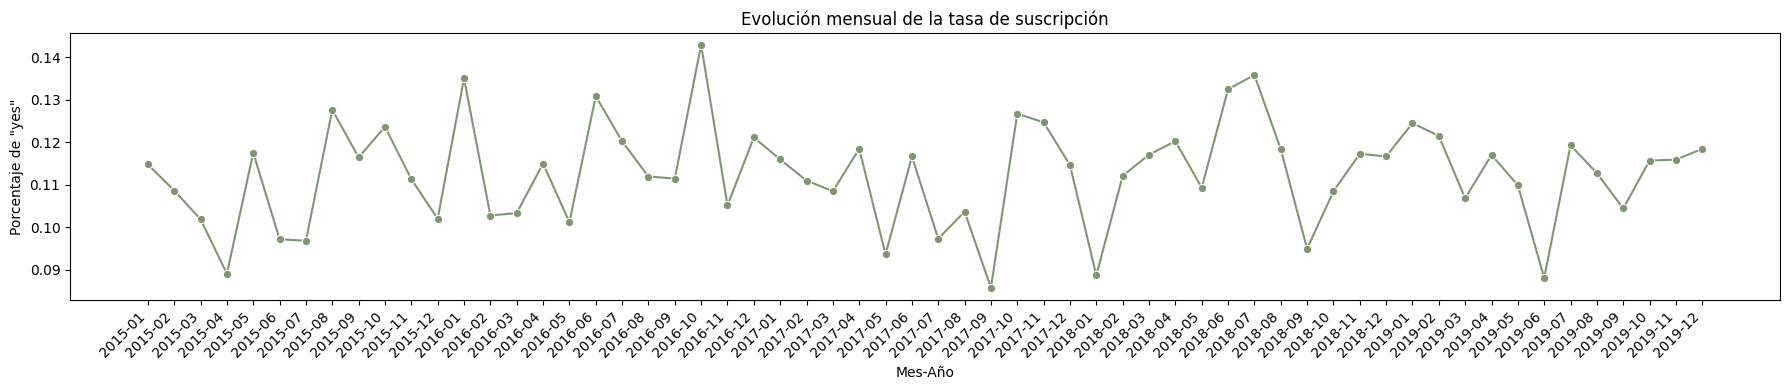

In [ ]:
# Tasa de suscripción por mes-año
tmp = (df_complete
       .groupby('YEAR_MONTH')['Y_BIN']
       .mean()
       .reset_index())

plt.figure(figsize=(18,4))
sns.lineplot(data=tmp, x='YEAR_MONTH', y='Y_BIN', marker='o', color='#809671')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Porcentaje de "yes"')
plt.xlabel('Mes-Año')
plt.title('Evolución mensual de la tasa de suscripción')
plt.tight_layout()
plt.show()

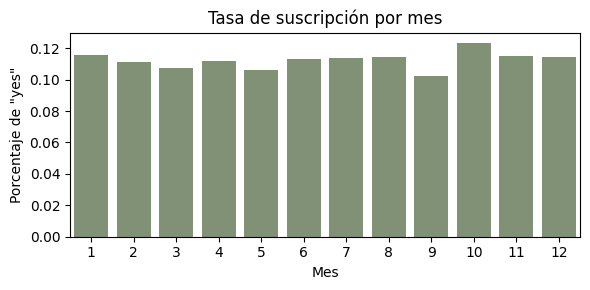

In [ ]:
# Tasa de suscripción por mes (estacionalidad)
tmp = (df_complete
       .groupby('MONTH')['Y_BIN']
       .mean()
       .reset_index())

plt.figure(figsize=(6,3))
sns.barplot(data=tmp, x='MONTH', y='Y_BIN', color='#809671')
plt.ylabel('Porcentaje de "yes"')
plt.xlabel('Mes')
plt.title('Tasa de suscripción por mes')
plt.tight_layout()
plt.show()

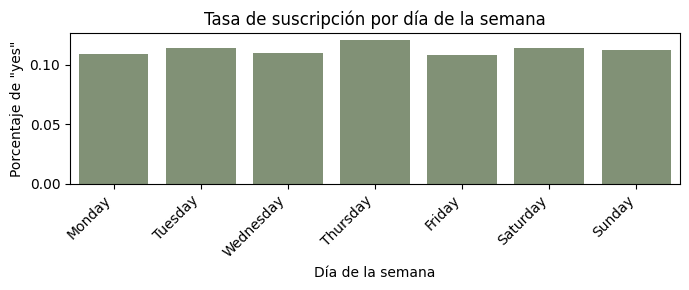

In [ ]:
# Tasa de suscripción por día de la semana
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
tmp = (df_complete
       .groupby('DOW')['Y_BIN']
       .mean()
       .reindex(order)
       .reset_index())

plt.figure(figsize=(7,3))
sns.barplot(data=tmp, x='DOW', y='Y_BIN', color='#809671')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Porcentaje de "yes"')
plt.xlabel('Día de la semana')
plt.title('Tasa de suscripción por día de la semana')
plt.tight_layout()
plt.show()

In [40]:
df_complete['YEAR_CUSTOMER']  = df_complete['DTCUSTOMER'].dt.year
df_complete['MONTH_CUSTOMER'] = df_complete['DTCUSTOMER'].dt.month
df_complete['DOW_CUSTOMER']   = df_complete['DTCUSTOMER'].dt.day_name()
df_complete['YEAR_MONTH_CUSTOMER'] = df_complete['DTCUSTOMER'].dt.to_period('M').astype(str)

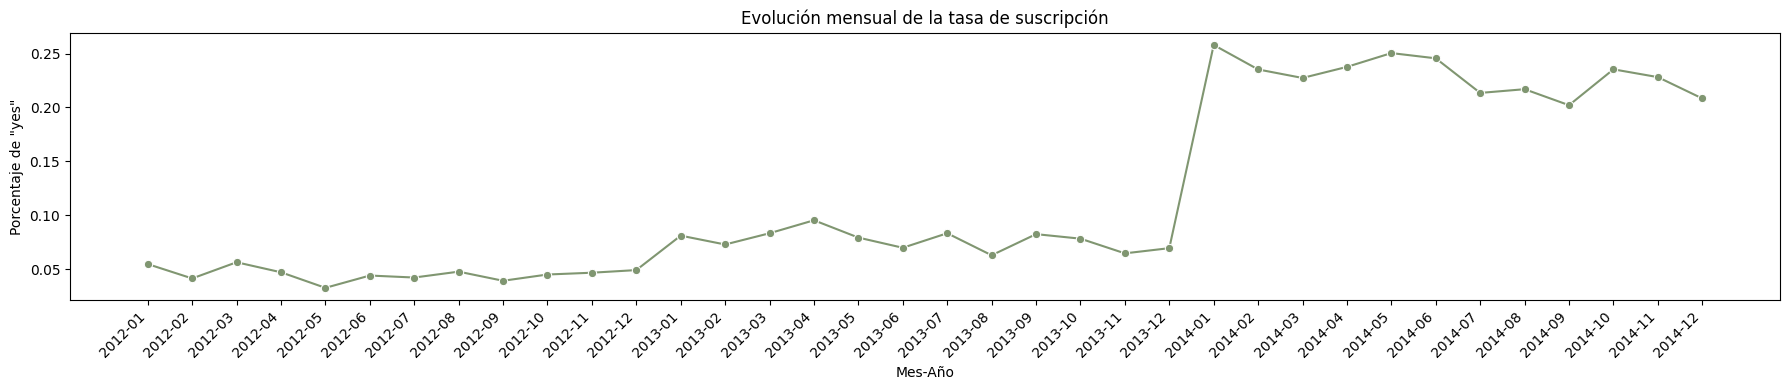

In [41]:
# Tasa de suscripción por mes-año
tmp = (df_complete
       .groupby('YEAR_MONTH_CUSTOMER')['Y_BIN']
       .mean()
       .reset_index())

plt.figure(figsize=(18,4))
sns.lineplot(data=tmp, x='YEAR_MONTH_CUSTOMER', y='Y_BIN', marker='o', color='#809671')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Porcentaje de "yes"')
plt.xlabel('Mes-Año')
plt.title('Evolución mensual de la tasa de suscripción')
plt.tight_layout()
plt.show()

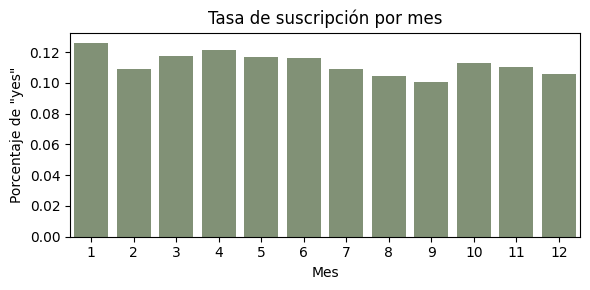

In [42]:
# Tasa de suscripción por mes (estacionalidad)
tmp = (df_complete
       .groupby('MONTH_CUSTOMER')['Y_BIN']
       .mean()
       .reset_index())

plt.figure(figsize=(6,3))
sns.barplot(data=tmp, x='MONTH_CUSTOMER', y='Y_BIN', color='#809671')
plt.ylabel('Porcentaje de "yes"')
plt.xlabel('Mes')
plt.title('Tasa de suscripción por mes')
plt.tight_layout()
plt.show()

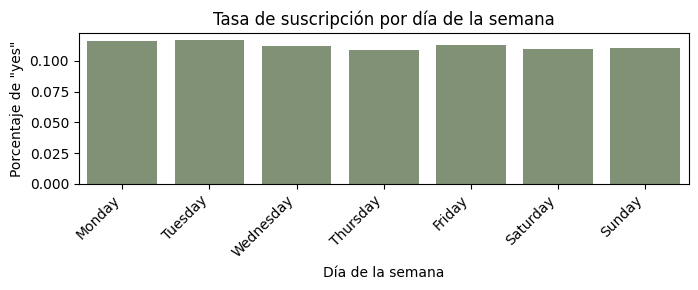

In [43]:
# Tasa de suscripción por día de la semana
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
tmp = (df_complete
       .groupby('DOW_CUSTOMER')['Y_BIN']
       .mean()
       .reindex(order)
       .reset_index())

plt.figure(figsize=(7,3))
sns.barplot(data=tmp, x='DOW_CUSTOMER', y='Y_BIN', color='#809671')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Porcentaje de "yes"')
plt.xlabel('Día de la semana')
plt.title('Tasa de suscripción por día de la semana')
plt.tight_layout()
plt.show()

### Conclusiones Variables Fecha:

1. `Fecha del contacto de campaña (DATE)`

El análisis temporal de la fecha de contacto muestra una sorprendente estabilidad en la tasa de suscripción. Entre 2015 y 2016 la conversión se mantiene en un rango muy estrecho, aproximadamente entre el 10.9 % y el 11.7 %, sin una tendencia clara de mejora o deterioro significativo. Por meses, octubre presenta la tasa algo más alta (en torno al 12.4 %) y septiembre la más baja (cerca del 10.3 %), pero la diferencia global no supera los 2 puntos porcentuales, por lo que no se identifica ningún “mes estrella” ni periodos críticos de bajo rendimiento. Algo similar ocurre por día de la semana: el jueves obtiene la tasa de éxito ligeramente superior (en torno al 12.1 %) mientras que el viernes se sitúa algo por debajo (aprox. 10.8 %), diferencias que, de nuevo, son marginales. En conjunto, estos resultados indican que el momento concreto del contacto (año, mes o día de la semana) apenas condiciona el resultado de la campaña, y que el foco de optimización debe ponerse más en el perfil del cliente y en la estrategia de segmentación que en el calendario.

2. `Fecha de alta como cliente (DTCUSTOMER)`

En contraste con la estabilidad del calendario de campaña, la fecha de alta del cliente sí revela diferencias muy marcadas en el comportamiento de suscripción. Los clientes incorporados en 2012 presentan una tasa de conversión cercana al 4.6 %, que aumenta hasta aproximadamente el 7.7 % para la cohorte de 2013 y se dispara hasta alrededor del 23 % para los clientes captados en 2014. Esto implica que los clientes de la cohorte 2014 son aproximadamente tres veces más propensos a contratar el producto que los de 2013 y hasta cinco veces más que los de 2012. Este patrón sugiere un cambio cualitativo en la estrategia de adquisición o en el tipo de cliente captado a partir de 2014, lo que convierte a la antigüedad en el banco y al año de alta en una dimensión clave para la segmentación comercial y el diseño de futuras campañas de marketing relacional.

## Conclusiones Finales del Análisis Exploratorio (EDA)
El análisis de los datos de campaña revela que los factores más determinantes para la suscripción a productos bancarios no son exclusivamente sociodemográficos, sino que dependen fuertemente de la relación previa con el cliente y de ciertos segmentos específicos. A continuación se detallan los hallazgos clave:

- **La relación previa es el predictor más potente**: Los clientes que han sido contactados con anterioridad presentan una tasa de conversión de 64.1%, frente al 9.2% de quienes no han sido contactados. Además, aquellos con historial de éxito en campañas anteriores muestran tasas de conversión superiores al 65%, lo que refuerza la importancia de la estrategia de retargeting y fidelización frente a la captación en frío.​

- **Segmento de alto valor**: clientes dados de alta en 2014: Este grupo destaca por una tasa de conversión del 23%, tres veces superior a la de clientes incorporados en años anteriores. Se recomienda priorizar la activación de esta base y estudiar el perfil de cliente captado en ese periodo para replicar estrategias exitosas.​

- **Perfil demográfico**: mayor receptividad en extremos del ciclo vital: Los estudiantes y jubilados muestran una propensión significativamente mayor a suscribirse, mientras que los clientes de edad media y empleo estable resultan más difíciles de convencer. Este patrón sugiere la conveniencia de adaptar la oferta y la comunicación a estos segmentos.​

- **Producto “refugio**”: correlación con el contexto económico: La suscripción se incrementa en contextos de tipos de interés bajos y empleo estancado, lo que indica que el producto actúa como alternativa de seguridad en momentos de incertidumbre económica. Esta dinámica debe considerarse en la planificación de campañas y en la gestión de portafolios.​

- **Factores operativos clave**: El canal móvil presenta una eficacia tres veces superior al teléfono fijo, y la duración de la conversación es un indicador relevante: mantener al cliente en contacto más de 5 minutos aumenta la probabilidad de éxito. No se observa una dependencia significativa de la estacionalidad, lo que permite una ejecución robusta de campañas durante todo el año.​